In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lgg-mri-segmentation/kaggle_3m/README.md
/kaggle/input/lgg-mri-segmentation/kaggle_3m/data.csv
/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif
/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif
/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_57.tif
/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif
/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_27.tif
/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_52.tif
/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_10.tif
/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_8_mask.tif
/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_34_mask.tif
/kaggle/input

<div style = "text-align: center;">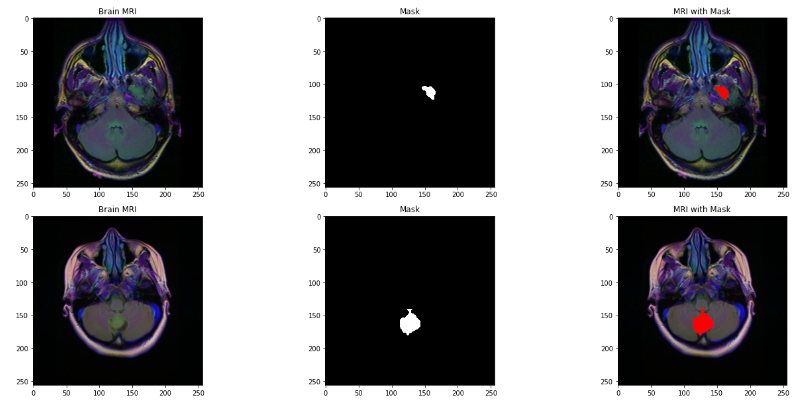</div>

**What's Brain Tumor ?** <br>
&nbsp;&nbsp;&nbsp;&nbsp;A brain tumor occurs when abnormal cells form within the brain. There are two main types of tumors: cancerous (malignant) tumors and benign (non-cancerous) tumors. Cancerous tumors can be divided into primary tumors, which start within the brain, and secondary tumors, which most commonly have spread from tumors located outside the brain, known as brain metastasis tumors. All types of brain tumors may produce symptoms that vary depending on the part of the brain involved. These symptoms may include headaches, seizures, problems with vision, vomiting and mental changes. The headache is classically worse in the morning and goes away with vomiting. Other symptoms may include difficulty walking, speaking or with sensations. As the disease progresses, unconsciousness may occur.<br>
**Semantic Segmentation** <br>
&nbsp;&nbsp;&nbsp;&nbsp;The goal of semantic image segmentation is to label each pixel of an image with a corresponding class of what is being represented. Because we’re predicting for every pixel in the image, this task is commonly referred to as dense prediction.

# import libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from skimage import io

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.python.keras import Sequential
from tensorflow.keras import layers, optimizers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
import tensorflow.keras.backend as K

from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.applications import VGG19

from warnings import filterwarnings
filterwarnings('ignore')

import random

import glob
from IPython.display import display

In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


# Prepare dataset

In [4]:
data = pd.read_csv('../input/lgg-mri-segmentation/kaggle_3m/data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient                    110 non-null    object 
 1   RNASeqCluster              92 non-null     float64
 2   MethylationCluster         109 non-null    float64
 3   miRNACluster               110 non-null    int64  
 4   CNCluster                  108 non-null    float64
 5   RPPACluster                98 non-null     float64
 6   OncosignCluster            105 non-null    float64
 7   COCCluster                 110 non-null    int64  
 8   histological_type          109 non-null    float64
 9   neoplasm_histologic_grade  109 non-null    float64
 10  tumor_tissue_site          109 non-null    float64
 11  laterality                 109 non-null    float64
 12  tumor_location             109 non-null    float64
 13  gender                     109 non-null    float64

In [5]:
data.head(10)

,Patient,RNASeqCluster,MethylationCluster,miRNACluster,CNCluster,RPPACluster,OncosignCluster,COCCluster,histological_type,neoplasm_histologic_grade,tumor_tissue_site,laterality,tumor_location,gender,age_at_initial_pathologic,race,ethnicity,death01
0,TCGA_CS_4941,2.0,4.0,2,2.0,NaN,3.0,2,1.0,2.0,1.0,3.0,2.0,2.0,67.0,3.0,2.0,1.0
1,TCGA_CS_4942,1.0,5.0,2,1.0,1.0,2.0,1,1.0,2.0,1.0,3.0,2.0,1.0,44.0,2.0,NaN,1.0
2,TCGA_CS_4943,1.0,5.0,2,1.0,2.0,2.0,1,1.0,2.0,1.0,1.0,2.0,2.0,37.0,3.0,NaN,0.0
3,TCGA_CS_4944,NaN,5.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0,3.0,6.0,2.0,50.0,3.0,NaN,0.0
4,TCGA_CS_5393,4.0,5.0,2,1.0,2.0,3.0,1,1.0,2.0,1.0,1.0,6.0,2.0,39.0,3.0,NaN,0.0
5,TCGA_CS_5395,2.0,4.0,2,2.0,NaN,3.0,2,3.0,1.0,1.0,3.0,5.0,2.0,43.0,2.0,NaN,1.0
6,TCGA_CS_5396,3.0,3.0,2,3.0,2.0,2.0,3,3.0,2.0,1.0,3.0,2.0,1.0,53.0,3.0,2.0,0.0
7,TCGA_CS_5397,NaN,4.0,1,2.0,3.0,3.0,2,1.0,2.0,1.0,1.0,6.0,1.0,54.0,3.0,2.0,1.0
8,TCGA_CS_6186,2.0,4.0,1,2.0,1.0,3.0,2,2.0,2.0,1.0,3.0,2.0,2.0,58.0,3.0,2.0,1.0
9,TCGA_CS_6188,2.0,4.0,3,2.0,3.0,3.0,2,1.0,2.0,1.0,3.0,6.0,2.0,48.0,3.0,2.0,0.0


In [6]:
data_map = []
for sub_dir_path in glob.glob("/kaggle/input/lgg-mri-segmentation/kaggle_3m/"+"*"):
    #if os.path.isdir(sub_path_dir):
    try:
        dir_name = sub_dir_path.split('/')[-1]
        for filename in os.listdir(sub_dir_path):
            image_path = sub_dir_path + '/' + filename
            data_map.extend([dir_name, image_path])
    except Exception as e:
        print(e)

[Errno 20] Not a directory: '/kaggle/input/lgg-mri-segmentation/kaggle_3m/README.md'
[Errno 20] Not a directory: '/kaggle/input/lgg-mri-segmentation/kaggle_3m/data.csv'


In [7]:
df = pd.DataFrame({"patient_id" : data_map[::2],
                   "path" : data_map[1::2]})
df.head()

,patient_id,path
0,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
1,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
2,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
4,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...


In [8]:
df_imgs = df[~df['path'].str.contains("mask")] # if have not mask
df_masks = df[df['path'].str.contains("mask")]# if have mask

# File path line length images for later sorting
BASE_LEN = 89 # len(/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_6404_19850629/TCGA_DU_6404_19850629_ <-!!!43.tif)
END_IMG_LEN = 4 # len(/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_6404_19850629/TCGA_DU_6404_19850629_43 !!!->.tif)
END_MASK_LEN = 9 # (/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_6404_19850629/TCGA_DU_6404_19850629_43 !!!->_mask.tif)

# Data sorting
imgs = sorted(df_imgs["path"].values, key=lambda x : int(x[BASE_LEN:-END_IMG_LEN]))
masks = sorted(df_masks["path"].values, key=lambda x : int(x[BASE_LEN:-END_MASK_LEN]))

# Sorting check
idx = random.randint(0, len(imgs)-1)
print("Path to the Image:", imgs[idx], "\nPath to the Mask:", masks[idx])

Path to the Image: /kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7008_19830723/TCGA_DU_7008_19830723_32.tif 
Path to the Mask: /kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7008_19830723/TCGA_DU_7008_19830723_32_mask.tif


In [9]:
# Final dataframe
brain_df = pd.DataFrame({"patient_id": df_imgs.patient_id.values,
                         "image_path": imgs,
                         "mask_path": masks
                        })
def pos_neg_diagnosis(mask_path):
    value = np.max(cv2.imread(mask_path))
    if value > 0 : 
        return 1
    else:
        return 0
    
brain_df['mask'] = brain_df['mask_path'].apply(lambda x: pos_neg_diagnosis(x))
brain_df

,patient_id,image_path,mask_path,mask
0,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
1,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
2,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
3,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
4,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
...,...,...,...,...
3924,TCGA_DU_7306_19930512,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
3925,TCGA_DU_7306_19930512,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
3926,TCGA_DU_7306_19930512,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
3927,TCGA_DU_7306_19930512,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0


# Vizualization

In [10]:
brain_df['mask'].value_counts()

mask
0    2556
1    1373
Name: count, dtype: int64

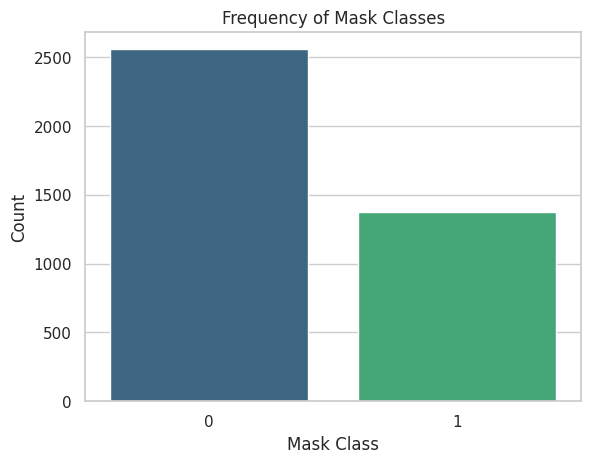

In [11]:
sns.set_theme(style="whitegrid")

# Plot the frequency of 0 and 1
sns.countplot(data=brain_df, x='mask', palette='viridis')

# Add labels and title
plt.title('Frequency of Mask Classes')
plt.xlabel('Mask Class')
plt.ylabel('Count')

plt.show()

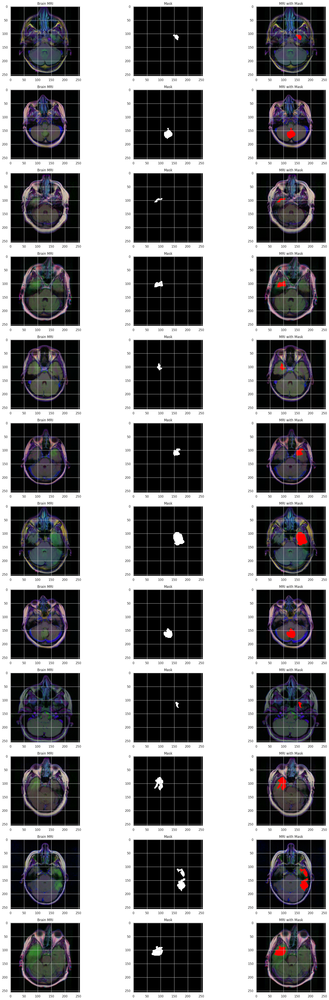

In [12]:
count = 0
i = 0
fig,axs = plt.subplots(12,3, figsize=(20,50))
for mask in brain_df['mask']:
    if (mask==1):
        img = io.imread(brain_df.image_path[i])
        axs[count][0].title.set_text("Brain MRI")
        axs[count][0].imshow(img)
        
        mask = io.imread(brain_df.mask_path[i])
        axs[count][1].title.set_text("Mask")
        axs[count][1].imshow(mask, cmap='gray')
        
        img[mask==255] = (255,0,0)  # change pixel color at the position of mask
        axs[count][2].title.set_text("MRI with Mask")
        axs[count][2].imshow(img)
        count +=1
    i += 1
    if (count==12):
        break
        
fig.tight_layout()

In [13]:
brain_df_train = brain_df.drop(columns=['patient_id'])
# Convert the data in mask column to string format, to use categorical mode in flow_from_dataframe
brain_df_train['mask'] = brain_df_train['mask'].apply(lambda x: str(x))
brain_df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  3929 non-null   object
 1   mask_path   3929 non-null   object
 2   mask        3929 non-null   object
dtypes: object(3)
memory usage: 92.2+ KB


# Preprocessing image

In [14]:
brain_df_mask = brain_df
brain_df_mask.shape

(3929, 4)

In [15]:
# creating test, train and val sets
X_train, X_val = train_test_split(brain_df_mask, test_size=0.15 ,random_state=42)
X_test, X_val = train_test_split(X_val, test_size=0.5, random_state=42)
print("Train size is {}, valid size is {} & test size is {}".format(len(X_train), len(X_val), len(X_test)))

train_ids = list(X_train.image_path)
train_mask = list(X_train.mask_path)

val_ids = list(X_val.image_path)
val_mask= list(X_val.mask_path)

Train size is 3339, valid size is 295 & test size is 295


In [16]:
class DataGenerator(tf.keras.utils.Sequence):
  def __init__(self, ids , mask, image_dir = './', batch_size = 16, img_h = 256, img_w = 256, shuffle = True, augment = False):

    self.ids = ids
    self.mask = mask
    self.image_dir = image_dir
    self.batch_size = batch_size
    self.img_h = img_h
    self.img_w = img_w
    self.shuffle = shuffle
    self.augment = augment
    self.on_epoch_end()

  def __len__(self):
    'Get the number of batches per epoch'

    return int(np.floor(len(self.ids)) / self.batch_size)

  def __getitem__(self, index):
    'Generate a batch of data'

    #generate index of batch_size length
    indexes = self.indexes[index* self.batch_size : (index+1) * self.batch_size]

    #get the ImageId corresponding to the indexes created above based on batch size
    list_ids = [self.ids[i] for i in indexes]

    #get the MaskId corresponding to the indexes created above based on batch size
    list_mask = [self.mask[i] for i in indexes]


    #generate data for the X(features) and y(label)
    X, y = self.__data_generation(list_ids, list_mask)

    #returning the data
    return X, y

  def on_epoch_end(self):
    'Used for updating the indices after each epoch, once at the beginning as well as at the end of each epoch'
    
    #getting the array of indices based on the input dataframe
    self.indexes = np.arange(len(self.ids))

    #if shuffle is true, shuffle the indices
    if self.shuffle:
      np.random.shuffle(self.indexes)

  def __augment(self, img, mask):
    'Apply the same random spatial transform to image + mask together, plus image-only intensity jitter'

    # random horizontal flip
    if np.random.rand() < 0.2:
      img = np.fliplr(img)
      mask = np.fliplr(mask)

    # random vertical flip
    if np.random.rand() < 0.2:
      img = np.flipud(img)
      mask = np.flipud(mask)

    # random rotation, same angle applied to image and mask
    if np.random.rand() < 0:
      angle = np.random.uniform(-15, 15)
      h, w = img.shape[:2]
      M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
      img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
      mask = cv2.warpAffine(mask, M, (w, h), borderMode=cv2.BORDER_REFLECT, flags=cv2.INTER_NEAREST)

    # random brightness/contrast jitter - image only, never touch the mask
    if np.random.rand() < 0.2:
      brightness = np.random.uniform(-15, 15)
      contrast = np.random.uniform(0.9, 1.1)
      img = img * contrast + brightness

    return img, mask

  def __data_generation(self, list_ids, list_mask):
    'generate the data corresponding the indexes in a given batch of images'

    # create empty arrays of shape (batch_size,height,width,depth) 
    #Depth is 3 for input and depth is taken as 1 for output becasue mask consist only of 1 channel.
    X = np.empty((self.batch_size, self.img_h, self.img_w, 3))
    y = np.empty((self.batch_size, self.img_h, self.img_w, 1))

    #iterate through the dataframe rows, whose size is equal to the batch_size
    for i in range(len(list_ids)):
      #path of the image
      img_path = str(list_ids[i])
      
      #mask path
      mask_path = str(list_mask[i])
      
      #reading the original image and the corresponding mask image
      img = io.imread(img_path)
      mask = io.imread(mask_path)

      #resizing and coverting them to array of type float64
      img = cv2.resize(img,(self.img_h,self.img_w))
      img = np.array(img, dtype = np.float64)
      
      mask = cv2.resize(mask,(self.img_h,self.img_w))
      mask = np.array(mask, dtype = np.float64)

      #apply data augmentation (training set only - see augment=True/False below)
      if self.augment:
        img, mask = self.__augment(img, mask)

      #standardising 
      img -= img.mean()
      img /= img.std()
      
      mask -= mask.mean()
      mask /= mask.std()
      
      #Adding image to the empty array
      X[i,] = img
      
      #expanding the dimnesion of the image from (256,256) to (256,256,1)
      y[i,] = np.expand_dims(mask, axis = 2)
    
    #normalizing y
    y = (y > 0).astype(int)

    return X, y

train_data = DataGenerator(train_ids, train_mask, augment = True)
val_data = DataGenerator(val_ids, val_mask, augment = False)


# Create Model

In [17]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, BatchNormalization, Activation, Concatenate
from tensorflow.keras.models import Model

def conv_block(input, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def decoder_block(input, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

def build_densenet121_unet(input_shape):
    """ Input """
    inputs = Input(input_shape)

    """ Pre-trained DenseNet121 """
    densenet = DenseNet121(include_top=False, weights="imagenet", input_tensor=inputs)

    """ Encoder skip connections """
    s0 = inputs                                    # 256x256x3   <- extra, DenseNet has no full-res block
    s1 = densenet.get_layer("conv1_relu").output   # 128x128x64
    s2 = densenet.get_layer("pool2_relu").output   # 64x64x256
    s3 = densenet.get_layer("pool3_relu").output   # 32x32x512

    """ Bridge """
    b1 = densenet.get_layer("pool4_relu").output   # 16x16x1024

    """ Decoder """
    d1 = decoder_block(b1, s3, 512)   # 32x32
    d2 = decoder_block(d1, s2, 256)   # 64x64
    d3 = decoder_block(d2, s1, 128)   # 128x128
    d4 = decoder_block(d3, s0, 64)    # 256x256   <- extra decoder stage using the raw input

    """ Output """
    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = Model(inputs, outputs, name="DenseNet121_U-Net")
    return model

model = build_densenet121_unet((256, 256, 3))
model.summary()

I0000 00:00:1790019374.618290      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790019374.621839      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

 Total params: 16,410,241 (62.60 MB)

 Trainable params: 16,352,961 (62.38 MB)

 Non-trainable params: 57,280 (223.75 KB)

## Training  Model

In [19]:
smooth = 1.0
TVERSKY_ALPHA = 0.7   # weight of false negatives; (1 - alpha) is the weight of false positives

def dice_coef_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = 2.0 * tf.reduce_sum(y_true * y_pred) + smooth
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    return 1.0 - intersection / union

def weighted_bce_loss(y_true, y_pred, fp_weight=1.0, fn_weight=2.0):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Avoid log(0)
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

    # False Negative:
    # y_true = 1, y_pred = 0
    fn_loss = y_true * tf.math.log(y_pred)

    # False Positive:
    # y_true = 0, y_pred = 1
    fp_loss = (1.0 - y_true) * tf.math.log(1.0 - y_pred)

    loss = -(fn_weight * fn_loss + fp_weight * fp_loss)

    return tf.reduce_mean(loss)


def weighted_bce_dice_loss(y_true, y_pred):
    wbce = weighted_bce_loss(
        y_true,
        y_pred,
    )
    dice_loss = dice_coef_loss(y_true, y_pred)
    return 0.5 * wbce + 0.5 * dice_loss

def tversky_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    alpha = TVERSKY_ALPHA
    true_pos = tf.reduce_sum(y_true * y_pred)
    false_neg = tf.reduce_sum(y_true * (1.0 - y_pred))
    false_pos = tf.reduce_sum((1.0 - y_true) * y_pred)
    return 1.0 - (true_pos + smooth) / (true_pos + alpha * false_neg + (1.0 - alpha) * false_pos + smooth)


def bce_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_coef_loss(y_true, y_pred) 
    
def iou_coef(y_true, y_pred, smooth=1e-6):
    """
    Computes the Intersection over Union (IoU) / Jaccard Index using TensorFlow.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    total_elements = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    union = total_elements - intersection

    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred, smooth=1e-6):
    """
    Computes the Dice Coefficient using TensorFlow.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    total_elements = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)

    return (2.0 * intersection + smooth) / (total_elements + smooth)

In [20]:
# compling model and callbacks functions
adam = tf.keras.optimizers.Adam(learning_rate=1e-3, epsilon = 0.1)
model.compile(optimizer = adam, 
                  loss = weighted_bce_dice_loss, 
                  metrics = [dice_coef, iou_coef]
                 )
#callbacks
earlystopping = EarlyStopping(monitor='val_loss',
                              mode='min', 
                              verbose=1, 
                              patience=30
                             )
# save the best model with lower validation loss
checkpointer = ModelCheckpoint(filepath="seg_model.h5", 
                               verbose=1, 
                               save_best_only=True
                              )
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              mode='min',
                              verbose=1,
                              patience=10,
                              min_delta=0.0001,
                              factor=0.2
                             )


In [ ]:
history = model.fit(train_data, 
                  epochs = 60, 
                  validation_data = val_data,
                  callbacks = [checkpointer, earlystopping, reduce_lr]
                 )

Epoch 1/60


2026-09-21 19:39:37.888928: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 19:39:38.119025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 19:39:46.405671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 19:39:46.678685: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[16,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01

208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - dice_coef: 0.0209 - iou_coef: 0.0106 - loss: 1.0132
Epoch 1: val_loss improved from None to 0.76721, saving model to seg_model.h5



Epoch 1: finished saving model to seg_model.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 363s 754ms/step - dice_coef: 0.0214 - iou_coef: 0.0109 - loss: 0.9186 - val_dice_coef: 0.0180 - val_iou_coef: 0.0091 - val_loss: 0.7672 - learning_rate: 0.0010
Epoch 2/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - dice_coef: 0.0281 - iou_coef: 0.0143 - loss: 0.6962
Epoch 2: val_loss improved from 0.76721 to 0.61582, saving model to seg_model.h5



Epoch 2: finished saving model to seg_model.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 149s 716ms/step - dice_coef: 0.0299 - iou_coef: 0.0152 - loss: 0.6579 - val_dice_coef: 0.0298 - val_iou_coef: 0.0151 - val_loss: 0.6158 - learning_rate: 0.0010
Epoch 3/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - dice_coef: 0.0429 - iou_coef: 0.0220 - loss: 0.5794
Epoch 3: val_loss improved from 0.61582 to 0.54058, saving model to seg_model.h5


...


Epoch 26: finished saving model to seg_model.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 149s 714ms/step - dice_coef: 0.8943 - iou_coef: 0.8108 - loss: 0.0587 - val_dice_coef: 0.8800 - val_iou_coef: 0.7880 - val_loss: 0.0651 - learning_rate: 0.0010
Epoch 27/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - dice_coef: 0.8799 - iou_coef: 0.8000 - loss: 0.0656
Epoch 27: val_loss did not improve from 0.06513
208/208 ━━━━━━━━━━━━━━━━━━━━ 146s 703ms/step - dice_coef: 0.8858 - iou_coef: 0.8045 - loss: 0.0627 - val_dice_coef: 0.8602 - val_iou_coef: 0.7609 - val_loss: 0.0756 - learning_rate: 0.0010
Epoch 28/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - dice_coef: 0.8947 - iou_coef: 0.8120 - loss: 0.0582
Epoch 28: val_loss did not improve from 0.06513
208/208 ━━━━━━━━━━━━━━━━━━━━ 147s 705ms/step - dice_coef: 0.8903 - iou_coef: 0.8062 - loss: 0.0605 - val_dice_coef: 0.8742 - val_iou_coef: 0.7789 - val_loss: 0.0679 - learning_rate: 0.0010
Epoch 29/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - dice_coef: 0.


Epoch 34: finished saving model to seg_model.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 148s 713ms/step - dice_coef: 0.8711 - iou_coef: 0.7829 - loss: 0.0713 - val_dice_coef: 0.8816 - val_iou_coef: 0.7913 - val_loss: 0.0645 - learning_rate: 0.0010
Epoch 35/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - dice_coef: 0.9048 - iou_coef: 0.8279 - loss: 0.0529
Epoch 35: val_loss did not improve from 0.06450
208/208 ━━━━━━━━━━━━━━━━━━━━ 146s 703ms/step - dice_coef: 0.9048 - iou_coef: 0.8280 - loss: 0.0528 - val_dice_coef: 0.8806 - val_iou_coef: 0.7893 - val_loss: 0.0650 - learning_rate: 0.0010
Epoch 36/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - dice_coef: 0.9075 - iou_coef: 0.8345 - loss: 0.0510
Epoch 36: val_loss did not improve from 0.06450
208/208 ━━━━━━━━━━━━━━━━━━━━ 147s 705ms/step - dice_coef: 0.9053 - iou_coef: 0.8316 - loss: 0.0523 - val_dice_coef: 0.8300 - val_iou_coef: 0.7442 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 37/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - dice_coef: 0.


Epoch 41: finished saving model to seg_model.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 148s 711ms/step - dice_coef: 0.9030 - iou_coef: 0.8321 - loss: 0.0530 - val_dice_coef: 0.8819 - val_iou_coef: 0.7938 - val_loss: 0.0640 - learning_rate: 0.0010
Epoch 42/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - dice_coef: 0.9067 - iou_coef: 0.8322 - loss: 0.0514
Epoch 42: val_loss did not improve from 0.06399
208/208 ━━━━━━━━━━━━━━━━━━━━ 147s 705ms/step - dice_coef: 0.9100 - iou_coef: 0.8373 - loss: 0.0497 - val_dice_coef: 0.8797 - val_iou_coef: 0.7891 - val_loss: 0.0654 - learning_rate: 0.0010
Epoch 43/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - dice_coef: 0.9219 - iou_coef: 0.8560 - loss: 0.0434
Epoch 43: val_loss did not improve from 0.06399
208/208 ━━━━━━━━━━━━━━━━━━━━ 146s 701ms/step - dice_coef: 0.9184 - iou_coef: 0.8501 - loss: 0.0453 - val_dice_coef: 0.7816 - val_iou_coef: 0.7000 - val_loss: 0.1134 - learning_rate: 0.0010
Epoch 44/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - dice_coef: 0.


Epoch 44: finished saving model to seg_model.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 148s 712ms/step - dice_coef: 0.9148 - iou_coef: 0.8444 - loss: 0.0472 - val_dice_coef: 0.8948 - val_iou_coef: 0.8119 - val_loss: 0.0580 - learning_rate: 0.0010
Epoch 45/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - dice_coef: 0.9139 - iou_coef: 0.8485 - loss: 0.0473
Epoch 45: val_loss did not improve from 0.05800
208/208 ━━━━━━━━━━━━━━━━━━━━ 147s 704ms/step - dice_coef: 0.9125 - iou_coef: 0.8439 - loss: 0.0482 - val_dice_coef: 0.8788 - val_iou_coef: 0.7875 - val_loss: 0.0660 - learning_rate: 0.0010
Epoch 46/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - dice_coef: 0.9157 - iou_coef: 0.8486 - loss: 0.0465
Epoch 46: val_loss did not improve from 0.05800
208/208 ━━━━━━━━━━━━━━━━━━━━ 146s 702ms/step - dice_coef: 0.9152 - iou_coef: 0.8484 - loss: 0.0468 - val_dice_coef: 0.8797 - val_iou_coef: 0.7874 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 47/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - dice_coef: 0.


Epoch 56: finished saving model to seg_model.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 148s 713ms/step - dice_coef: 0.9275 - iou_coef: 0.8661 - loss: 0.0402 - val_dice_coef: 0.8960 - val_iou_coef: 0.8132 - val_loss: 0.0572 - learning_rate: 2.0000e-04
Epoch 57/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - dice_coef: 0.9293 - iou_coef: 0.8687 - loss: 0.0392
Epoch 57: val_loss did not improve from 0.05723
208/208 ━━━━━━━━━━━━━━━━━━━━ 146s 703ms/step - dice_coef: 0.9300 - iou_coef: 0.8700 - loss: 0.0388 - val_dice_coef: 0.8825 - val_iou_coef: 0.7931 - val_loss: 0.0640 - learning_rate: 2.0000e-04
Epoch 58/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - dice_coef: 0.9284 - iou_coef: 0.8673 - loss: 0.0395
Epoch 58: val_loss did not improve from 0.05723
208/208 ━━━━━━━━━━━━━━━━━━━━ 146s 701ms/step - dice_coef: 0.9313 - iou_coef: 0.8723 - loss: 0.0381 - val_dice_coef: 0.8894 - val_iou_coef: 0.8044 - val_loss: 0.0606 - learning_rate: 2.0000e-04
Epoch 59/60
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - d

In [33]:
model = load_model("seg_model.h5", compile=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=weighted_bce_dice_loss, 
    metrics=[iou_coef, dice_coef]
)

print("Model loaded and compiled successfully!")

Model loaded and compiled successfully!


## Model Evaluation

In [34]:
history.history.keys()

dict_keys(['dice_coef', 'iou_coef', 'loss', 'val_dice_coef', 'val_iou_coef', 'val_loss', 'learning_rate'])

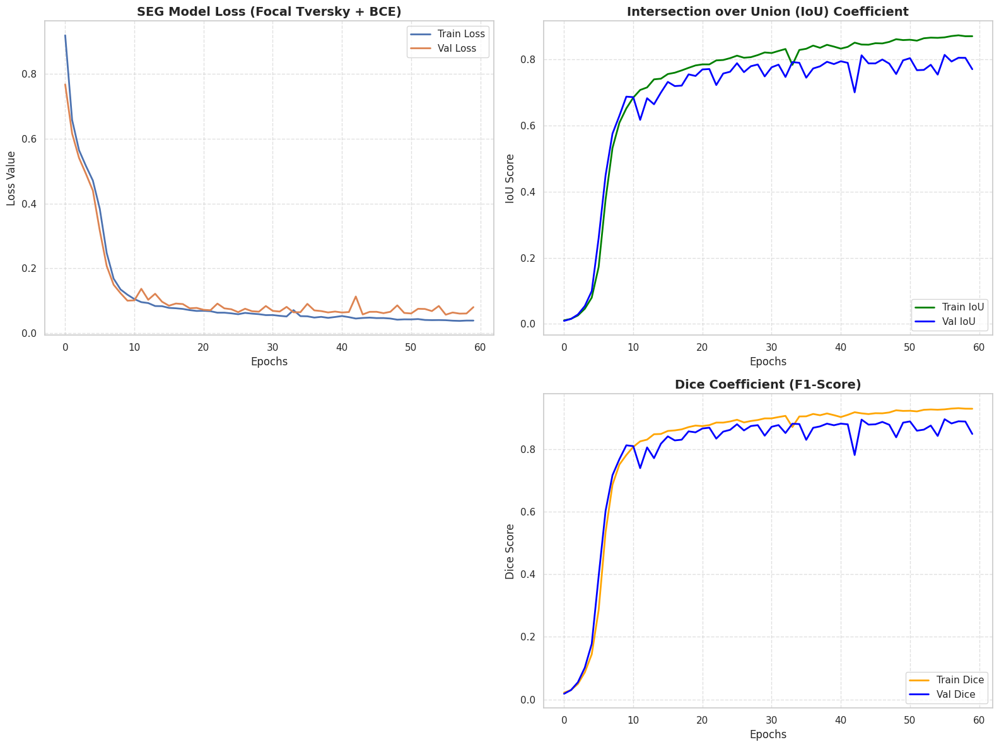

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.title("SEG Model Loss (Focal Tversky + BCE)", fontsize=14, fontweight='bold')
plt.ylabel("Loss Value", fontsize=12)
plt.xlabel("Epochs", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(2, 2, 2)
plt.plot(history.history['iou_coef'], label='Train IoU', linewidth=2, color='green')
plt.plot(history.history['val_iou_coef'], label='Val IoU', linewidth=2, color='blue')
plt.title("Intersection over Union (IoU) Coefficient", fontsize=14, fontweight='bold')
plt.ylabel("IoU Score", fontsize=12)
plt.xlabel("Epochs", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(2, 2, 4)
plt.plot(history.history['dice_coef'], label='Train Dice', linewidth=2, color='orange')
plt.plot(history.history['val_dice_coef'], label='Val Dice', linewidth=2, color='blue')
plt.title("Dice Coefficient (F1-Score)", fontsize=14, fontweight='bold')
plt.ylabel("Dice Score", fontsize=12)
plt.xlabel("Epochs", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [36]:
test_ids = list(X_test.image_path)
test_mask = list(X_test.mask_path)

## Segmantatiın Model Performance 

In [37]:
def prediction(test, model_seg):
  
    # empty list to store results
    mask, image_id,has_mask = [], [], []
    
    #itetrating through each image in test data
    for i in test.image_path:
        

        
        #Creating a empty array of shape 1,256,256,1
        X = np.empty((1,256,256,3))
        # read the image
        img = io.imread(i)
        #resizing the image and coverting them to array of type float64
        img = cv2.resize(img, (256,256))
        img = np.array(img, dtype=np.float64)
        
        # standardising the image
        img -= img.mean()
        img /= img.std()
        #converting the shape of image from 256,256,3 to 1,256,256,3
        X[0,] = img
        
        #make prediction of mask
        predict = model_seg.predict(X)
        
        # if sum of predicted mask is 0 then there is not tumour
        if predict.round().astype(int).sum()==0:
            image_id.append(i)
            has_mask.append(0)
            mask.append('No mask :)')
        else:
        #if the sum of pixel values are more than 0, then there is tumour
            image_id.append(i)
            has_mask.append(1)
            mask.append(predict)
            
    return pd.DataFrame({'image_path': image_id,'predicted_mask': mask,'has_mask': has_mask})


In [38]:
# making prediction
df_pred = prediction(X_test, model)
df_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━

,image_path,predicted_mask,has_mask
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,No mask :),0
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,"[[[[1.626551e-05], [4.5417135e-05], [1.843359e...",1
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,"[[[[1.5666003e-05], [4.114148e-05], [1.8313336...",1
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,No mask :),0
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,No mask :),0
...,...,...,...
290,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,"[[[[1.7169192e-05], [4.080864e-05], [1.7705086...",1
291,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,"[[[[1.6670487e-05], [2.105064e-05], [1.436393e...",1
292,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,No mask :),0
293,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,No mask :),0


In [39]:
# merging original and prediction df
df_pred = X_test.merge(df_pred, on='image_path')
df_pred.head(10)

,patient_id,image_path,mask_path,mask,predicted_mask,has_mask
0,TCGA_CS_6667_20011105,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,No mask :),0
1,TCGA_DU_6405_19851005,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1,"[[[[1.626551e-05], [4.5417135e-05], [1.843359e...",1
2,TCGA_DU_6407_19860514,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1,"[[[[1.5666003e-05], [4.114148e-05], [1.8313336...",1
3,TCGA_CS_6668_20011025,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,No mask :),0
4,TCGA_HT_7882_19970125,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,No mask :),0
5,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,No mask :),0
6,TCGA_CS_6666_20011109,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1,"[[[[1.7524588e-05], [4.2667973e-05], [2.611113...",1
7,TCGA_FG_A4MU_20030903,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,No mask :),0
8,TCGA_DU_6400_19830518,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,No mask :),0
9,TCGA_DU_8165_19970205,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,No mask :),0


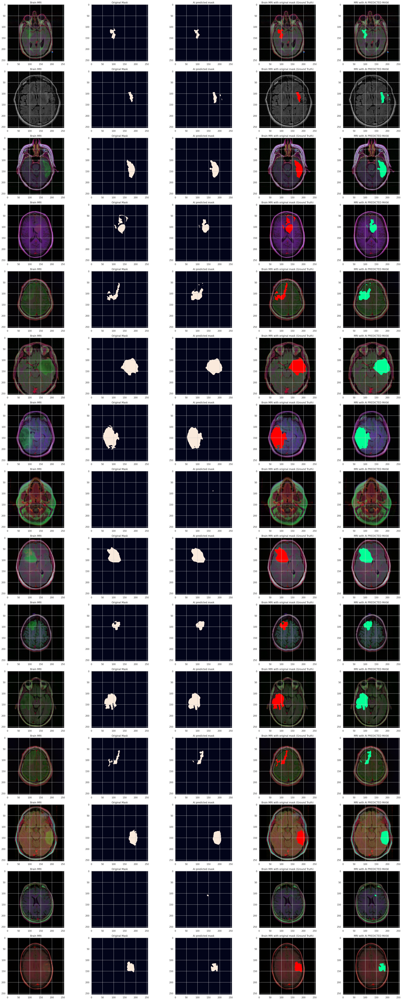

In [40]:
#visualizing prediction
count = 0
fig, axs = plt.subplots(15,5, figsize=(30,70))

for i in range(len(df_pred)):
    if df_pred.has_mask[i]==1 and count<15:
        #read mri images
        img = io.imread(df_pred.image_path[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[count][0].imshow(img)
        axs[count][0].title.set_text('Brain MRI')
        
        #read original mask
        mask = io.imread(df_pred.mask_path[i])
        axs[count][1].imshow(mask)
        axs[count][1].title.set_text('Original Mask')
        
        #read predicted mask
        pred = np.array(df_pred.predicted_mask[i]).squeeze().round()
        axs[count][2].imshow(pred)
        axs[count][2].title.set_text('AI predicted mask')
        
        #overlay original mask with MRI
        img[mask==255] = (255,0,0)
        axs[count][3].imshow(img)
        axs[count][3].title.set_text('Brain MRI with original mask (Ground Truth)')
        
        #overlay predicted mask and MRI
        img_ = io.imread(df_pred.image_path[i])
        img_ = cv2.cvtColor(img_, cv2.COLOR_BGR2RGB)
        img_[pred==1] = (0,255,150)
        axs[count][4].imshow(img_)
        axs[count][4].title.set_text('MRI with AI PREDICTED MASK')
        
        count +=1
    if (count==15):
        break

fig.tight_layout()        


## Quantitative Evaluation (Dice, IoU, Pixel Accuracy, Precision/Recall)

Plain pixel accuracy is misleading here because the tumor region is a small fraction of each slice (a model that predicts "no tumor" everywhere would still score 90%+ pixel accuracy). The metrics below are the standard ones for segmentation: **Dice coefficient** and **IoU** measure mask overlap, while precision/recall on the tumor class show whether the model is missing tumors (low recall) or over-predicting them (low precision). Pixel accuracy is included too, only to make the imbalance problem visible by comparison.


In [41]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten().astype(np.float64)
    y_pred_f = y_pred.flatten().astype(np.float64)
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten().astype(np.float64)
    y_pred_f = y_pred.flatten().astype(np.float64)
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def pixel_accuracy(y_true, y_pred):
    return np.mean(y_true.flatten() == y_pred.flatten())

def precision_recall(y_true, y_pred, eps=1e-6):
    y_true_f = y_true.flatten().astype(np.float64)
    y_pred_f = y_pred.flatten().astype(np.float64)
    tp = np.sum(y_true_f * y_pred_f)
    fp = np.sum((1 - y_true_f) * y_pred_f)
    fn = np.sum(y_true_f * (1 - y_pred_f))
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    return precision, recall


In [42]:
# Compute metrics for every test image using the predictions already stored in df_pred
results = []

for i in range(len(df_pred)):
    # ground truth mask, resized to match model output and binarized (0/255 -> 0/1)
    gt = io.imread(df_pred.mask_path[i])
    gt = cv2.resize(gt, (256, 256))
    gt = (gt > 0).astype(np.uint8)

    if df_pred.has_mask[i] == 1:
        # predicted_mask is the raw sigmoid output (1,256,256,1) -> binarize
        pred = np.array(df_pred.predicted_mask[i]).squeeze()
        pred = (pred.round()).astype(np.uint8)
    else:
        # model predicted an empty mask
        pred = np.zeros((256, 256), dtype=np.uint8)

    dice = dice_coef(gt, pred)
    iou = iou_coef(gt, pred)
    pix_acc = pixel_accuracy(gt, pred)
    precision, recall = precision_recall(gt, pred)

    results.append({
        "image_path": df_pred.image_path[i],
        "dice": dice,
        "iou": iou,
        "pixel_accuracy": pix_acc,
        "precision": precision,
        "recall": recall
    })

metrics_df = pd.DataFrame(results)
metrics_df.head(10)


,image_path,dice,iou,pixel_accuracy,precision,recall
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.000000,1.000000,1.000000,1.000000,1.000000
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0.836207,0.718519,0.997101,0.958498,0.741590
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0.808811,0.678994,0.996689,0.742718,0.887814
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.000000,1.000000,1.000000,1.000000,1.000000
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.000000,1.000000,1.000000,1.000000,1.000000
5,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.000000,1.000000,1.000000,1.000000,1.000000
6,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0.928686,0.866867,0.995941,0.896480,0.963293
7,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.000000,1.000000,1.000000,1.000000,1.000000
8,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.000000,1.000000,1.000000,1.000000,1.000000
9,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1.000000,1.000000,1.000000,1.000000,1.000000


In [45]:
# Summary: mean +/- std across the test set -- this is your real comparable "accuracy" number
summary = metrics_df[["dice", "iou", "pixel_accuracy", "precision", "recall"]].agg(["mean", "std"])
print("Test set segmentation performance (VGG19-UNet baseline):")
print(summary)

print(f"\nMean Dice coefficient: {metrics_df['dice'].mean():.4f}")
print(f"Mean IoU:              {metrics_df['iou'].mean():.4f}")
print(f"Mean pixel accuracy:   {metrics_df['pixel_accuracy'].mean():.4f}  <- inflated by class imbalance, not the number to trust")
print(f"Mean precision:        {metrics_df['precision'].mean():.4f}")
print(f"Mean recall:           {metrics_df['recall'].mean():.4f}")


Test set segmentation performance (VGG19-UNet baseline):
          dice       iou  pixel_accuracy  precision    recall
mean  0.910869  0.880961        0.998091   0.937648  0.934839
std   0.214643  0.231725        0.003223   0.170984  0.165047

Mean Dice coefficient: 0.9109
Mean IoU:              0.8810
Mean pixel accuracy:   0.9981  <- inflated by class imbalance, not the number to trust
Mean precision:        0.9376
Mean recall:           0.9348


**How to read this:**
- `Mean Dice` and `Mean IoU` are the numbers to report as "model accuracy" and to compare across runs (baseline vs. modified models) — use these in your ablation table.
- `Mean pixel accuracy` is shown only to demonstrate why it's misleading here — expect it to look artificially high.
- If `precision` is much lower than `recall`, the model is over-predicting tumor regions (false positives). If `recall` is much lower than `precision`, it's missing real tumor regions (false negatives) — useful for deciding which knob to turn next (e.g. Focal Tversky alpha).


## Error Analysis

The DenseNet121-U-Net run reaches **0.79 mean IoU**. To find concrete ways to push that higher, this section digs into *where* the model is wrong rather than just *how wrong* on average — using an aggregate confusion matrix, the distribution of per-image scores, a check for whether tumor size predicts failure, and visual overlays of the worst-performing slices.


In [50]:
from sklearn.metrics import confusion_matrix


### 1. Aggregate pixel-level confusion matrix

Per-image Dice/IoU tells you the overall score, but a single confusion matrix summed over every pixel in the test set shows the *type* of error the model makes most: is it missing tumor pixels (false negatives) or hallucinating tumor where there isn't one (false positives)?


In [51]:
# Recompute per-image TP/FP/FN/TN pixel counts (cheap -- reuses predictions already stored in df_pred,
# no model inference needed) and build one analysis dataframe with everything in one place.
analysis_rows = []

for i in range(len(df_pred)):
    gt = io.imread(df_pred.mask_path[i])
    gt = cv2.resize(gt, (256, 256))
    gt = (gt > 0).astype(np.uint8)

    if df_pred.has_mask[i] == 1:
        pred = np.array(df_pred.predicted_mask[i]).squeeze()
        pred = (pred.round()).astype(np.uint8)
    else:
        pred = np.zeros((256, 256), dtype=np.uint8)

    gt_f, pred_f = gt.flatten(), pred.flatten()
    tp = int(np.sum((gt_f == 1) & (pred_f == 1)))
    fp = int(np.sum((gt_f == 0) & (pred_f == 1)))
    fn = int(np.sum((gt_f == 1) & (pred_f == 0)))
    tn = int(np.sum((gt_f == 0) & (pred_f == 0)))

    analysis_rows.append({
        "image_path": df_pred.image_path[i],
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "gt_area": int(gt_f.sum()),        # ground-truth tumor size in pixels
        "pred_area": int(pred_f.sum()),    # predicted tumor size in pixels
    })

analysis_df = pd.DataFrame(analysis_rows).merge(metrics_df, on="image_path")
analysis_df.head(10)


,image_path,tp,fp,fn,tn,gt_area,pred_area,dice,iou,pixel_accuracy,precision,recall
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,1.000000,1.000000,1.000000,1.000000,1.000000
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,485,21,169,64861,654,506,0.836207,0.718519,0.997101,0.958498,0.741590
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,459,159,58,64860,517,618,0.808811,0.678994,0.996689,0.742718,0.887814
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,1.000000,1.000000,1.000000,1.000000,1.000000
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,1.000000,1.000000,1.000000,1.000000,1.000000
5,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,1.000000,1.000000,1.000000,1.000000,1.000000
6,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1732,200,66,63538,1798,1932,0.928686,0.866867,0.995941,0.896480,0.963293
7,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,1.000000,1.000000,1.000000,1.000000,1.000000
8,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,1.000000,1.000000,1.000000,1.000000,1.000000
9,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,1.000000,1.000000,1.000000,1.000000,1.000000


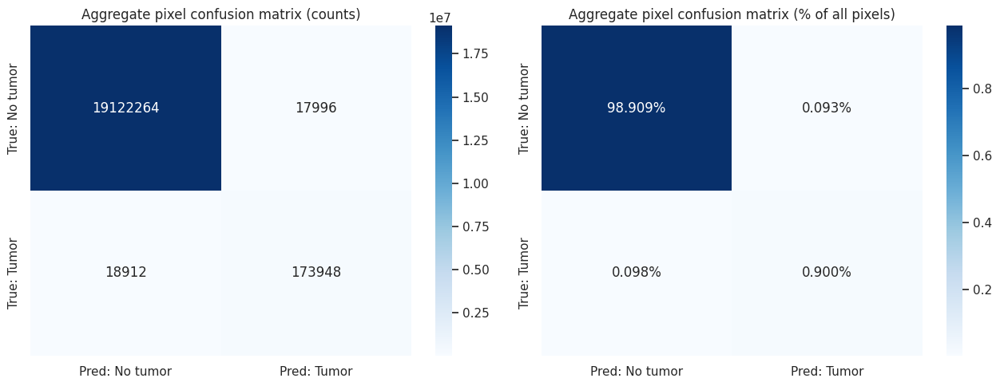

False negative pixels: 18,912  (tumor missed)
False positive pixels: 17,996  (healthy tissue predicted as tumor)
FN/FP ratio: 1.05  -- >1 means the model under-segments more than it over-segments


In [54]:
# Sum pixel-level TP/FP/FN/TN across the whole test set and plot as a confusion matrix
agg_tp = analysis_df.tp.sum()
agg_fp = analysis_df.fp.sum()
agg_fn = analysis_df.fn.sum()
agg_tn = analysis_df.tn.sum()

cm = np.array([[agg_tn, agg_fp],
               [agg_fn, agg_tp]])
cm_norm = cm / cm.sum()

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No tumor", "Pred: Tumor"],
            yticklabels=["True: No tumor", "True: Tumor"], ax=axs[0])
axs[0].set_title("Aggregate pixel confusion matrix (counts)")

sns.heatmap(cm_norm, annot=True, fmt=".3%", cmap="Blues",
            xticklabels=["Pred: No tumor", "Pred: Tumor"],
            yticklabels=["True: No tumor", "True: Tumor"], ax=axs[1])
axs[1].set_title("Aggregate pixel confusion matrix (% of all pixels)")
plt.tight_layout()
plt.show()

print(f"False negative pixels: {agg_fn:,}  (tumor missed)")
print(f"False positive pixels: {agg_fp:,}  (healthy tissue predicted as tumor)")
print(f"FN/FP ratio: {agg_fn/max(agg_fp,1):.2f}  -- >1 means the model under-segments more than it over-segments")


### 2. Distribution of per-image Dice/IoU

A mean of 0.79 could mean "every image scores close to 0.79" or "most images score ~0.9 and a handful of bad failures drag the average down." These two situations call for very different fixes, so it's worth checking the shape of the distribution, not just the mean.


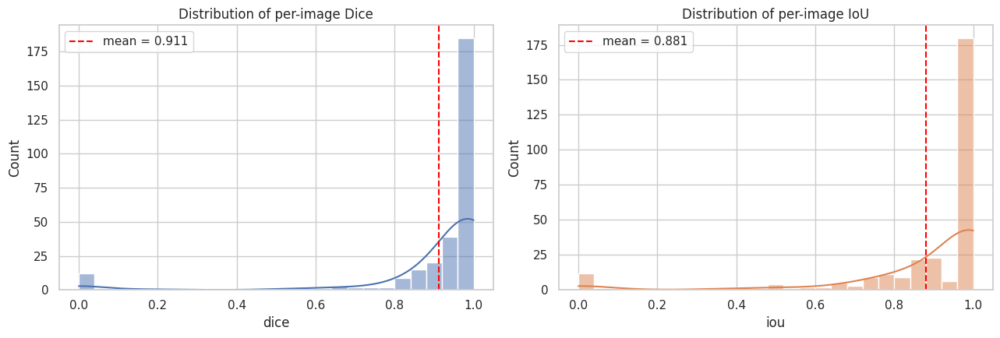

Fraction of test images with IoU < 0.5: 6.8%
Worst 5 IoU scores: [8.438818558279477e-10, 1.838235290738538e-09, 6.849315021580034e-09, 8.130081234714787e-09, 1.4925372911561597e-08]


In [55]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(analysis_df['dice'], bins=25, kde=True, ax=axs[0], color="#4C72B0")
axs[0].axvline(analysis_df['dice'].mean(), color="red", linestyle="--", label=f"mean = {analysis_df['dice'].mean():.3f}")
axs[0].set_title("Distribution of per-image Dice")
axs[0].legend()

sns.histplot(analysis_df['iou'], bins=25, kde=True, ax=axs[1], color="#DD8452")
axs[1].axvline(analysis_df['iou'].mean(), color="red", linestyle="--", label=f"mean = {analysis_df['iou'].mean():.3f}")
axs[1].set_title("Distribution of per-image IoU")
axs[1].legend()
plt.tight_layout()
plt.show()

low_iou_frac = (analysis_df['iou'] < 0.5).mean()
print(f"Fraction of test images with IoU < 0.5: {low_iou_frac:.1%}")
print(f"Worst 5 IoU scores: {sorted(analysis_df['iou'])[:5]}")


### 3. Does tumor size predict failure?

A very common segmentation failure mode is that small tumors are disproportionately hard — a few missed pixels on a small tumor tanks IoU, while the same pixel error on a large tumor barely moves it. Plotting IoU against ground-truth tumor size checks whether that's happening here, which directly informs the fix (e.g. size-aware loss weighting, or the Focal Tversky alpha/gamma sweep from the proposal).


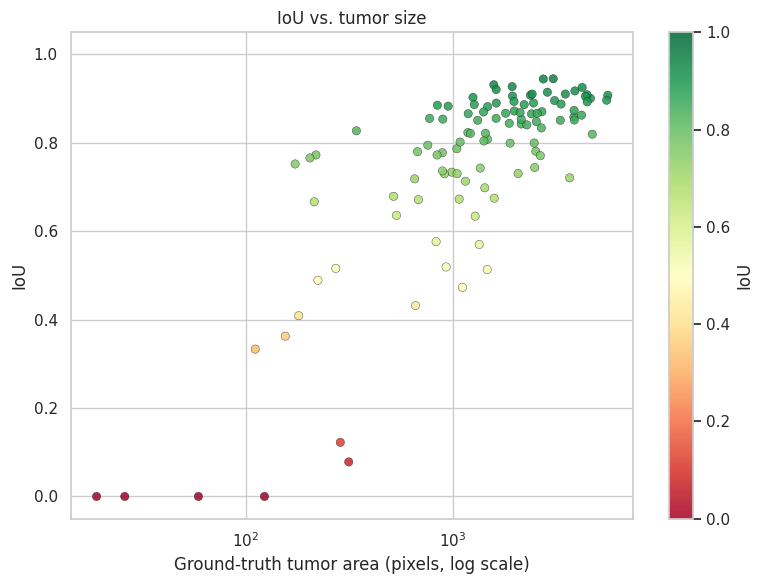

Correlation between tumor area and IoU: -0.107
(positive = larger tumors score higher; a strong positive value confirms the small-tumor failure mode)


In [56]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(analysis_df['gt_area'], analysis_df['iou'], c=analysis_df['iou'],
                 cmap="RdYlGn", vmin=0, vmax=1, edgecolor="k", linewidth=0.3, alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("Ground-truth tumor area (pixels, log scale)")
ax.set_ylabel("IoU")
ax.set_title("IoU vs. tumor size")
plt.colorbar(sc, label="IoU")
plt.tight_layout()
plt.show()

corr = analysis_df['gt_area'].corr(analysis_df['iou'])
print(f"Correlation between tumor area and IoU: {corr:.3f}")
print("(positive = larger tumors score higher; a strong positive value confirms the small-tumor failure mode)")


### 4. Visual inspection of the worst cases

Numbers tell you *how much* the model is wrong; the overlays below show *what kind* of mistake it's making on the specific slices with the lowest IoU. Green = correct tumor pixels (true positive), red = predicted tumor that isn't there (false positive), blue = missed tumor (false negative).


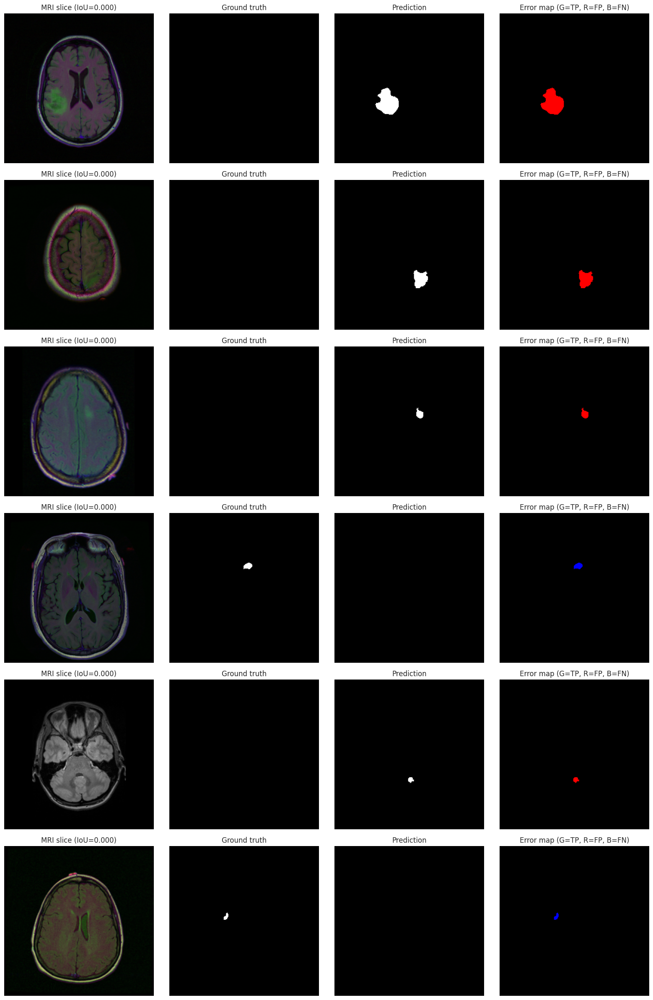

In [57]:
def error_overlay(gt, pred):
    """ RGB overlay: green=TP, red=FP, blue=FN, black=TN """
    overlay = np.zeros((*gt.shape, 3), dtype=np.uint8)
    overlay[(gt == 1) & (pred == 1)] = [0, 255, 0]     # TP - green
    overlay[(gt == 0) & (pred == 1)] = [255, 0, 0]     # FP - red
    overlay[(gt == 1) & (pred == 0)] = [0, 0, 255]     # FN - blue
    return overlay

worst_k = analysis_df.nsmallest(6, "iou").reset_index(drop=True)

fig, axs = plt.subplots(len(worst_k), 4, figsize=(16, 4 * len(worst_k)))
for row, r in worst_k.iterrows():
    img = io.imread(r.image_path)
    img = cv2.resize(img, (256, 256))

    gt = io.imread(df_pred.loc[df_pred.image_path == r.image_path, "mask_path"].values[0])
    gt = cv2.resize(gt, (256, 256))
    gt = (gt > 0).astype(np.uint8)

    pred_raw = df_pred.loc[df_pred.image_path == r.image_path, "predicted_mask"].values[0]
    pred = np.zeros((256, 256), dtype=np.uint8) if isinstance(pred_raw, str) else np.array(pred_raw).squeeze().round().astype(np.uint8)

    overlay = error_overlay(gt, pred)

    axs[row, 0].imshow(img); axs[row, 0].set_title(f"MRI slice (IoU={r.iou:.3f})"); axs[row, 0].axis("off")
    axs[row, 1].imshow(gt, cmap="gray"); axs[row, 1].set_title("Ground truth"); axs[row, 1].axis("off")
    axs[row, 2].imshow(pred, cmap="gray"); axs[row, 2].set_title("Prediction"); axs[row, 2].axis("off")
    axs[row, 3].imshow(overlay); axs[row, 3].set_title("Error map (G=TP, R=FP, B=FN)"); axs[row, 3].axis("off")

plt.tight_layout()
plt.show()


### 5. Summary and next steps

Fill in this checklist based on what the plots above actually show for this run:

- **FN/FP ratio (Section 1):** if false negatives dominate, the model is under-segmenting (missing tumor) — consider raising Focal Tversky's alpha further, or check Section 3 for a small-tumor pattern. If false positives dominate, the model over-segments — a morphological opening pass (post-processing) or a lower alpha may help.
- **Score distribution (Section 2):** if most of the test set scores well above 0.79 and a small number of bad failures pull the mean down, focus effort on understanding those specific failures (Section 4) rather than retuning the whole pipeline.
- **Size correlation (Section 3):** a strong positive correlation confirms small tumors are the weak point — targeted fixes include elastic augmentation on small-tumor slices specifically, or a loss term that upweights small regions.
- **Visual patterns (Section 4):** look for a *consistent* failure type across the worst cases — e.g. always missing the tumor boundary (FN ring around a correctly-found core), always a small stray FP blob elsewhere in the slice, or complete misses on slices where the tumor is very faint. Each of those points to a different fix (boundary-aware loss, post-processing, or better augmentation, respectively) — write down which one you see most before moving to the next encoder/architecture run, so the comparison across runs tracks whether that specific failure mode actually improved.


## Training-set behavior analysis

The test-set error analysis showed that false-positive pixels may be larger than false-negative pixels. Before changing the architecture or loss, we can check whether the **same over-segmentation behavior already exists on the training set**.

This section runs inference on `X_train` **without augmentation**, then compares training-set and test-set Dice/IoU, false positives/false negatives, and predicted-vs-ground-truth tumor area. If the training set is also strongly over-segmented, the behavior is not only a generalization problem.


In [58]:
# Helper: run inference on a dataframe in batches, without training augmentation
def predict_split_no_augmentation(df, model_seg, batch_size=16):
    image_paths = list(df.image_path)
    mask_paths = list(df.mask_path)
    rows = []

    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start:start + batch_size]
        batch_mask_paths = mask_paths[start:start + batch_size]

        X = np.empty((len(batch_paths), 256, 256, 3), dtype=np.float32)

        for j, path in enumerate(batch_paths):
            img = io.imread(path)
            img = cv2.resize(img, (256, 256))
            img = np.asarray(img, dtype=np.float32)

            # Same preprocessing used by the original prediction() function
            mean = img.mean()
            std = img.std()
            if std < 1e-8:
                std = 1.0
            X[j] = (img - mean) / std

        preds = model_seg.predict(X, verbose=0)

        for j, (image_path, mask_path) in enumerate(zip(batch_paths, batch_mask_paths)):
            gt = io.imread(mask_path)
            gt = cv2.resize(gt, (256, 256), interpolation=cv2.INTER_NEAREST)
            gt = (gt > 0).astype(np.uint8)

            pred_prob = np.asarray(preds[j]).squeeze()
            pred = (pred_prob >= 0.5).astype(np.uint8)

            gt_f = gt.flatten()
            pred_f = pred.flatten()

            tp = int(np.sum((gt_f == 1) & (pred_f == 1)))
            fp = int(np.sum((gt_f == 0) & (pred_f == 1)))
            fn = int(np.sum((gt_f == 1) & (pred_f == 0)))
            tn = int(np.sum((gt_f == 0) & (pred_f == 0)))

            dice = dice_coef(gt, pred)
            iou = iou_coef(gt, pred)
            precision, recall = precision_recall(gt, pred)

            gt_area = int(gt.sum())
            pred_area = int(pred.sum())

            rows.append({
                'image_path': image_path,
                'mask_path': mask_path,
                'tp': tp,
                'fp': fp,
                'fn': fn,
                'tn': tn,
                'gt_area': gt_area,
                'pred_area': pred_area,
                'area_ratio': pred_area / max(gt_area, 1),
                'dice': dice,
                'iou': iou,
                'precision': precision,
                'recall': recall
            })

    return pd.DataFrame(rows)


In [59]:
# Run the model on the COMPLETE training split.
# IMPORTANT: augmentation is disabled here because we want to measure
# the model's actual behavior on the original training images.
train_analysis_df = predict_split_no_augmentation(X_train, model, batch_size=16)

print(f"Training images evaluated: {len(train_analysis_df)} / {len(X_train)}")
train_analysis_df.head()


2026-09-21 22:24:10.646018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 22:24:10.954396: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 22:24:15.161680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 22:24:15.392273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-21 22:24:15.717176: E external/local_xla/xla/stream_

Training images evaluated: 3339 / 3339


,image_path,mask_path,tp,fp,fn,tn,gt_area,pred_area,area_ratio,dice,iou,precision,recall
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,0.0,1.0,1.0,1.0,1.0
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,0.0,1.0,1.0,1.0,1.0
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,0.0,1.0,1.0,1.0,1.0
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,0.0,1.0,1.0,1.0,1.0
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,0,0,65536,0,0,0.0,1.0,1.0,1.0,1.0


In [60]:
# Training-set quantitative summary
train_summary = train_analysis_df[['dice', 'iou', 'precision', 'recall', 'area_ratio']].agg(['mean', 'std'])

print("Training-set segmentation performance:")
print(train_summary)

train_fp = train_analysis_df['fp'].sum()
train_fn = train_analysis_df['fn'].sum()
train_tp = train_analysis_df['tp'].sum()

print(f"\nAggregate TP pixels: {train_tp:,}")
print(f"False positive pixels: {train_fp:,}")
print(f"False negative pixels: {train_fn:,}")
print(f"FN/FP ratio: {train_fn / max(train_fp, 1):.2f}")
print(f"Mean predicted/GT tumor-area ratio: {train_analysis_df['area_ratio'].mean():.2f}x")
print(f"Median predicted/GT tumor-area ratio: {train_analysis_df['area_ratio'].median():.2f}x")
print(f"Images with predicted area > 1.25x GT area: {(train_analysis_df['area_ratio'] > 1.25).mean():.1%}")
print(f"Images with predicted area > 1.50x GT area: {(train_analysis_df['area_ratio'] > 1.50).mean():.1%}")


Training-set segmentation performance:
          dice       iou  precision    recall  area_ratio
mean  0.968828  0.949033   0.971415  0.973885    0.367299
std   0.091164  0.111226   0.067031  0.082273    0.643443

Aggregate TP pixels: 2,214,998
False positive pixels: 135,026
False negative pixels: 87,544
FN/FP ratio: 0.65
Mean predicted/GT tumor-area ratio: 0.37x
Median predicted/GT tumor-area ratio: 0.00x
Images with predicted area > 1.25x GT area: 0.4%
Images with predicted area > 1.50x GT area: 0.3%


### Train vs. test: is over-segmentation already present during training?

For over-segmentation, inspect:

- **FP pixels**: healthy pixels incorrectly labeled as tumor.
- **FN pixels**: tumor pixels missed by the model.
- **Predicted/GT area ratio**: values consistently above 1 indicate that the predicted tumor is larger than the ground truth.

A similar FP-heavy pattern on both train and test suggests that the behavior is learned by the model/loss/threshold rather than being caused only by unseen test images.


In [61]:
# Compare the existing test analysis with the new training analysis
comparison = pd.DataFrame({
    'Train': [
        train_analysis_df['dice'].mean(),
        train_analysis_df['iou'].mean(),
        train_analysis_df['precision'].mean(),
        train_analysis_df['recall'].mean(),
        train_analysis_df['fp'].sum(),
        train_analysis_df['fn'].sum(),
        train_analysis_df['area_ratio'].mean(),
        train_analysis_df['area_ratio'].median()
    ],
    'Test': [
        analysis_df['dice'].mean(),
        analysis_df['iou'].mean(),
        analysis_df['precision'].mean(),
        analysis_df['recall'].mean(),
        analysis_df['fp'].sum(),
        analysis_df['fn'].sum(),
        (analysis_df['pred_area'] / analysis_df['gt_area'].clip(lower=1)).mean(),
        (analysis_df['pred_area'] / analysis_df['gt_area'].clip(lower=1)).median()
    ]
}, index=[
    'Mean Dice',
    'Mean IoU',
    'Mean Precision',
    'Mean Recall',
    'Total FP pixels',
    'Total FN pixels',
    'Mean predicted/GT area ratio',
    'Median predicted/GT area ratio'
])

print(comparison)


                                        Train          Test
Mean Dice                            0.968828      0.910869
Mean IoU                             0.949033      0.880961
Mean Precision                       0.971415      0.937648
Mean Recall                          0.973885      0.934839
Total FP pixels                 135026.000000  17996.000000
Total FN pixels                  87544.000000  18912.000000
Mean predicted/GT area ratio         0.367299      7.205274
Median predicted/GT area ratio       0.000000      0.000000


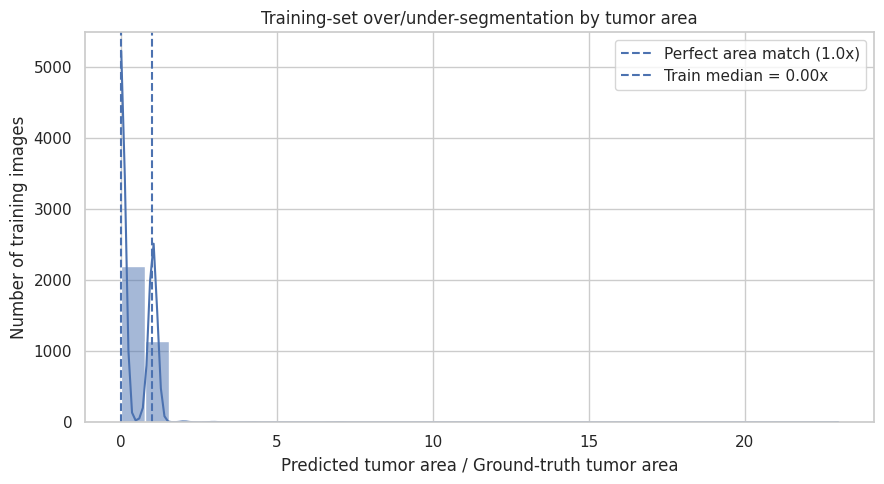

In [62]:
# Visualize the distribution of predicted-vs-ground-truth tumor area ratio
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(train_analysis_df['area_ratio'], bins=30, kde=True, ax=ax)
ax.axvline(1.0, linestyle='--', label='Perfect area match (1.0x)')
ax.axvline(
    train_analysis_df['area_ratio'].median(),
    linestyle='--',
    label=f"Train median = {train_analysis_df['area_ratio'].median():.2f}x"
)
ax.set_xlabel('Predicted tumor area / Ground-truth tumor area')
ax.set_ylabel('Number of training images')
ax.set_title('Training-set over/under-segmentation by tumor area')
ax.legend()
plt.tight_layout()
plt.show()


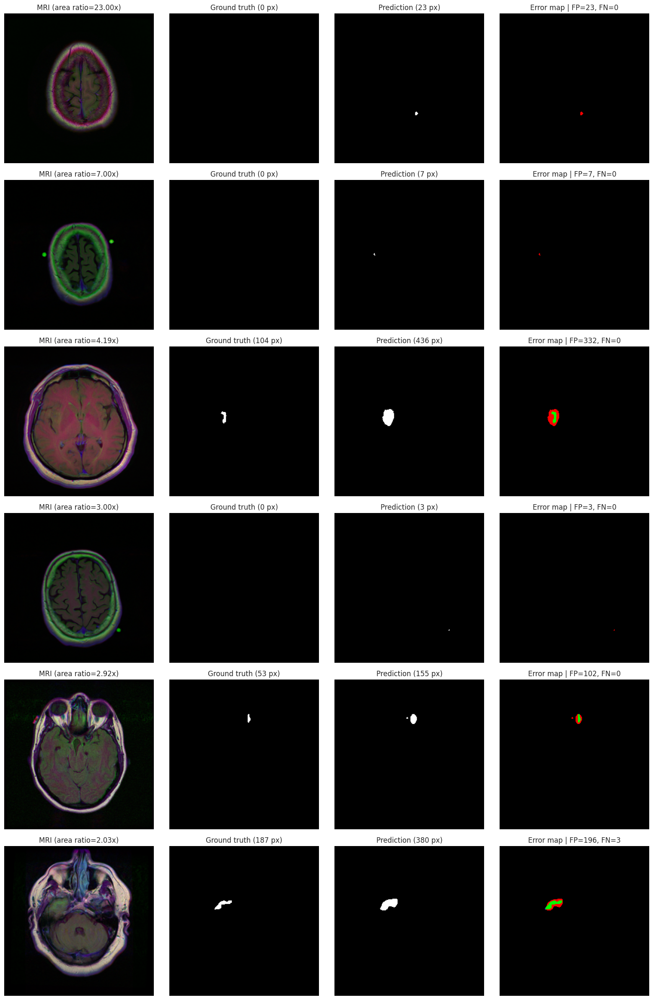

In [63]:
# Training images with the strongest over-segmentation
overseg_train = train_analysis_df.sort_values('area_ratio', ascending=False).head(6).reset_index(drop=True)

fig, axs = plt.subplots(len(overseg_train), 4, figsize=(16, 4 * len(overseg_train)))
if len(overseg_train) == 1:
    axs = np.expand_dims(axs, axis=0)

for row, r in overseg_train.iterrows():
    img = io.imread(r.image_path)
    img = cv2.resize(img, (256, 256))

    gt = io.imread(r.mask_path)
    gt = cv2.resize(gt, (256, 256), interpolation=cv2.INTER_NEAREST)
    gt = (gt > 0).astype(np.uint8)

    # Re-run only this image to display the raw sigmoid prediction.
    x = img.astype(np.float32)
    mean, std = x.mean(), x.std()
    if std < 1e-8:
        std = 1.0
    x = ((x - mean) / std)[None, ...]

    pred_prob = model.predict(x, verbose=0).squeeze()
    pred = (pred_prob >= 0.5).astype(np.uint8)

    overlay = error_overlay(gt, pred)

    axs[row, 0].imshow(img)
    axs[row, 0].set_title(f"MRI (area ratio={r.area_ratio:.2f}x)")
    axs[row, 0].axis('off')

    axs[row, 1].imshow(gt, cmap='gray')
    axs[row, 1].set_title(f"Ground truth ({r.gt_area:,} px)")
    axs[row, 1].axis('off')

    axs[row, 2].imshow(pred, cmap='gray')
    axs[row, 2].set_title(f"Prediction ({r.pred_area:,} px)")
    axs[row, 2].axis('off')

    axs[row, 3].imshow(overlay)
    axs[row, 3].set_title(f"Error map | FP={r.fp:,}, FN={r.fn:,}")
    axs[row, 3].axis('off')

plt.tight_layout()
plt.show()


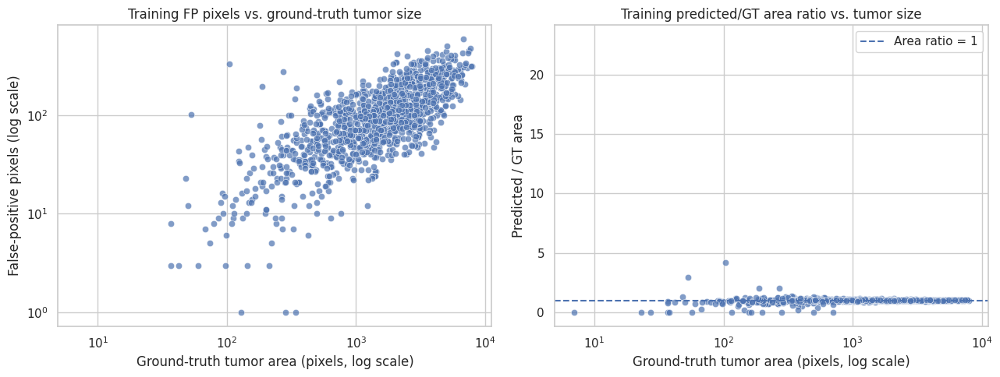

Train correlation (GT area vs area ratio): 0.535


In [64]:
# Training-set FP/FN behavior per image
train_analysis_df['fp_fraction_of_prediction'] = (
    train_analysis_df['fp'] / train_analysis_df['pred_area'].clip(lower=1)
)
train_analysis_df['fn_fraction_of_gt'] = (
    train_analysis_df['fn'] / train_analysis_df['gt_area'].clip(lower=1)
)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=train_analysis_df, x='gt_area', y='fp', ax=axs[0], alpha=0.7)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_title('Training FP pixels vs. ground-truth tumor size')
axs[0].set_xlabel('Ground-truth tumor area (pixels, log scale)')
axs[0].set_ylabel('False-positive pixels (log scale)')

sns.scatterplot(data=train_analysis_df, x='gt_area', y='area_ratio', ax=axs[1], alpha=0.7)
axs[1].axhline(1.0, linestyle='--', label='Area ratio = 1')
axs[1].set_xscale('log')
axs[1].set_title('Training predicted/GT area ratio vs. tumor size')
axs[1].set_xlabel('Ground-truth tumor area (pixels, log scale)')
axs[1].set_ylabel('Predicted / GT area')
axs[1].legend()

plt.tight_layout()
plt.show()

print(
    f"Train correlation (GT area vs area ratio): "
    f"{train_analysis_df['gt_area'].corr(train_analysis_df['area_ratio']):.3f}"
)
